# Shark Attacks

**Problem Statement**

Shark conservation organizations need evidence-based insights to identify where and under which circumstances shark-human interactions occur most frequently. Understanding the role of human activities, shark species, and geographic hotspots can help promote safer ocean practices while supporting shark conservation efforts and sustainable tourism policies.

_**Hypothesis 1**_

-> Fatal shark attacks occur more frequently in provoked incidents than in unprovoked incidents.
[If proven true, we could argue that the general public overestimate the danger posed by sharks based on unfunded allegations]

_**Hypothesis 2**_

-> A small number of shark species account for the majority of reported shark attacks worldwide.
[If proven true, we could argue that most shark species pose little threat to humans as opposed to public opinion]

_**Hypothesis 3**_

-> Shark-human interactions are concentrated in a small number of countries—particularly the United States and Australia—and are most frequently associated with surfing.

## Data cleaning

### Loading data

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
url = "https://www.sharkattackfile.net/spreadsheets/GSAF5.xls"

In [6]:
df = pd.read_excel(url, engine="xlrd")

### General Cleaning

In [7]:
#droping unnecessary columns
df.drop(columns = ['Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'], inplace = True)

In [8]:
#convert all columns' names to lowercase
df.columns = df.columns.str.lower()
#replace space with underscore in colum name (only one)
df.rename(columns= {'fatal y/n': 'fatal_y/n'}, inplace=True)
df

,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species
0,6th June,2026.0,Unprovoked,Australia,Western Australia,Michaelmas Island King George Sound,Spearfishing,Daniel Turpin,M,35,Critical head injuries,Y,1125hrs,Great White shark 4.5 m
1,1st June,2026.0,Unprovoked,Brazil,Recife,Boa Via gem beach,Swimming,Marcela Vitoria de Lima Santos,F,19,Bite wounds to lower limbs leg amputated in ho...,N,1643hrs,Tiger shark 3m
2,1st June,2026.0,Unprovoked,Brazil,Jaboatao dos Guarapes,PierrebBeach,Swimming,Joao Lucas Castro Nemezio,M,11,Bite wounds to hand hip and leg left leg amput...,N,1340 hrs,Bull shark
3,31st May,2026.0,Unprovoked,Australia,NSW,Red Cliff beach Yuraygir National Park,Surfing,Alejo Santinaque,M,20,Bite wounds to right foot,N,dusk,Bull shark
4,30th May,2026.0,Unprovoked,USA,Hawaii,Cromwell's beach Oahu,Paddling surfboard,Unknown male,M,38,Serious injuries to lower legs,N,0630hrs,2.4m (8ft) shark
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7092,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN
7093,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN
7094,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN
7095,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN


In [9]:
#there were no rows with only null values
df.dropna(how = "all", inplace = True) 
df

,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species
0,6th June,2026.0,Unprovoked,Australia,Western Australia,Michaelmas Island King George Sound,Spearfishing,Daniel Turpin,M,35,Critical head injuries,Y,1125hrs,Great White shark 4.5 m
1,1st June,2026.0,Unprovoked,Brazil,Recife,Boa Via gem beach,Swimming,Marcela Vitoria de Lima Santos,F,19,Bite wounds to lower limbs leg amputated in ho...,N,1643hrs,Tiger shark 3m
2,1st June,2026.0,Unprovoked,Brazil,Jaboatao dos Guarapes,PierrebBeach,Swimming,Joao Lucas Castro Nemezio,M,11,Bite wounds to hand hip and leg left leg amput...,N,1340 hrs,Bull shark
3,31st May,2026.0,Unprovoked,Australia,NSW,Red Cliff beach Yuraygir National Park,Surfing,Alejo Santinaque,M,20,Bite wounds to right foot,N,dusk,Bull shark
4,30th May,2026.0,Unprovoked,USA,Hawaii,Cromwell's beach Oahu,Paddling surfboard,Unknown male,M,38,Serious injuries to lower legs,N,0630hrs,2.4m (8ft) shark
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7092,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN
7093,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN
7094,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN
7095,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN


In [ ]:
df.duplicated().sum()
df[df.duplicated()] #shows the duplicated rows

In [ ]:
#duplicates eliminated
df = df.drop_duplicates().copy()
df

### Cleaning Per Series

#### Date

#### Year

In [10]:
#indicates the number of null values in year
df["year"].isnull().sum()

np.int64(2)

In [11]:
#Replace the null values by the year when the accident was reported
df.loc[950, "year"] = 2017 
df.loc[6865, "year"] = 1836

In [12]:
#converts the year column(float) to int
df["year"] = df["year"].astype(int)
df

,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species
0,6th June,2026,Unprovoked,Australia,Western Australia,Michaelmas Island King George Sound,Spearfishing,Daniel Turpin,M,35,Critical head injuries,Y,1125hrs,Great White shark 4.5 m
1,1st June,2026,Unprovoked,Brazil,Recife,Boa Via gem beach,Swimming,Marcela Vitoria de Lima Santos,F,19,Bite wounds to lower limbs leg amputated in ho...,N,1643hrs,Tiger shark 3m
2,1st June,2026,Unprovoked,Brazil,Jaboatao dos Guarapes,PierrebBeach,Swimming,Joao Lucas Castro Nemezio,M,11,Bite wounds to hand hip and leg left leg amput...,N,1340 hrs,Bull shark
3,31st May,2026,Unprovoked,Australia,NSW,Red Cliff beach Yuraygir National Park,Surfing,Alejo Santinaque,M,20,Bite wounds to right foot,N,dusk,Bull shark
4,30th May,2026,Unprovoked,USA,Hawaii,Cromwell's beach Oahu,Paddling surfboard,Unknown male,M,38,Serious injuries to lower legs,N,0630hrs,2.4m (8ft) shark
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7092,Before 1903,0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN
7093,Before 1903,0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN
7094,1900-1905,0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN
7095,1883-1889,0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN


#### Type

In [13]:
#consolidates all types of attacks in only five -> it's possible to consolidate it even more
df["type"] = df["type"].replace({
    " Provoked":"Provoked",
    "unprovoked":"Unprovoked",
    "UNprovoked":"Unprovoked",
    "Unconfirmed":"Unknown",
    "?":"Unknown",
    "Unverified":"Unknown",
    "Under investigation":"Unknown",
    "Questionable":"Unknown",
    "Invalid":"Unknown",
    "Sea Disaster":"Accident",
    "Boat":"Watercraft"})

In [14]:
#shows the new value counts for type
df["type"].value_counts()

type
Unprovoked    5247
Provoked       645
Unknown        583
Watercraft     362
Accident       242
Name: count, dtype: int64

In [15]:
#after checking the most frequent value per country, "Unprovoked" will replace the null values
df["type"] = df["type"].fillna("Unprovoked") 

#### Country

In [16]:
#capitalizes only the first letter of the string in country and state columns
df["country"] = df["country"].str.title() 
df["state"] = df["state"].str.title()
df

,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species
0,6th June,2026,Unprovoked,Australia,Western Australia,Michaelmas Island King George Sound,Spearfishing,Daniel Turpin,M,35,Critical head injuries,Y,1125hrs,Great White shark 4.5 m
1,1st June,2026,Unprovoked,Brazil,Recife,Boa Via gem beach,Swimming,Marcela Vitoria de Lima Santos,F,19,Bite wounds to lower limbs leg amputated in ho...,N,1643hrs,Tiger shark 3m
2,1st June,2026,Unprovoked,Brazil,Jaboatao Dos Guarapes,PierrebBeach,Swimming,Joao Lucas Castro Nemezio,M,11,Bite wounds to hand hip and leg left leg amput...,N,1340 hrs,Bull shark
3,31st May,2026,Unprovoked,Australia,Nsw,Red Cliff beach Yuraygir National Park,Surfing,Alejo Santinaque,M,20,Bite wounds to right foot,N,dusk,Bull shark
4,30th May,2026,Unprovoked,Usa,Hawaii,Cromwell's beach Oahu,Paddling surfboard,Unknown male,M,38,Serious injuries to lower legs,N,0630hrs,2.4m (8ft) shark
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7092,Before 1903,0,Unprovoked,Australia,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN
7093,Before 1903,0,Unprovoked,Australia,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN
7094,1900-1905,0,Unprovoked,Usa,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN
7095,1883-1889,0,Unprovoked,Panama,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN


In [17]:
#Fills null values with "Unknown" for homogeneization
df["country"] = df["country"].fillna("Unknown")

In [18]:
df["country"].value_counts()

country
Usa                   2583
Australia             1533
South Africa           599
New Zealand            146
Bahamas                142
                      ... 
Bahrein                  1
Korea                    1
Red Sea?                 1
Asia?                    1
Ceylon (Sri Lanka)       1
Name: count, Length: 222, dtype: int64

In [19]:
#checks for unique country values
df["country"].unique()

<StringArray>
[               'Australia',                   'Brazil',
                      'Usa',                   'Hawaii',
                 'Maldives',                  'Bahamas',
            'New Caledonia',           'Cayman Islands',
        'Us Virgin Islands',               'Mozambique',
 ...
        'Mediterranean Sea',                   'Sweden',
                   'Roatan', 'Between Portugal & India',
                 'Djibouti',                  'Bahrein',
                    'Korea',                 'Red Sea?',
                    'Asia?',       'Ceylon (Sri Lanka)']
Length: 222, dtype: str

In [20]:
#removes whitespaces before and after the string
df["country"] = df["country"].str.strip()

In [21]:
#corrects all country names
df["country"] = df["country"].replace({
  # Spelling corrections
    "Columbia": "Colombia",
    "Maldive Islands": "Maldives",
    "Turks And Caicos": "Turks & Caicos",
    "United Arab Emirates (Uae)": "United Arab Emirates",
    "Western Samoa": "Samoa",
    "Ceylon": "Sri Lanka",
    "Ceylon (Sri Lanka)": "Sri Lanka",
    "Bahrein": "Bahrain",
    "Burma": "Myanmar",

    # Country standardization
    "England": "United Kingdom",
    "Scotland": "United Kingdom",
    "Federated States Of Micronesia": "Micronesia",
    "Nevis": "St Kitts & Nevis",
    "St Kitts / Nevis": "St Kitts & Nevis",
    "Trinidad": "Trinidad & Tobago",
    "Tobago": "Trinidad & Tobago",
    "Korea": "South Korea",
    "British New Guinea": "Papua New Guinea",
    "New Guinea": "Papua New Guinea",
    "San Domingo": "Dominican Republic",
    "Antigua": "Antigua & Barbuda",

    # Islands and territories
    "Hawaii": "Hawaii (United States)",
    "Canary Islands": "Canary Islands (Spain)",
    "Azores": "Azores (Portugal)",
    "Roatan": "Roatan (Honduras)",
    "Okinawa": "Okinawa (Japan)",
    "Java": "Java (Indonesia)",
    "Crete": "Crete (Greece)",
    "Curacao": "Curacao (Netherlands)",
    "Guam": "Guam (United States)",
    "Martinique": "Martinique (France)",
    "Mayotte": "Mayotte (France)",
    "Diego Garcia": "Diego Garcia (United Kingdom)",
    "Johnston Island": "Johnston Island (United States)",
    "Grand Cayman": "Grand Cayman (Cayman Islands)",
    "British Virgin Islands": "British Virgin Islands (United Kingdom)",
    "Us Virgin Islands": "Virgin Islands (United States)",
    "Aruba": "Aruba (Netherlands)",
    "Netherlands Antilles": "Netherlands Antilles (Netherlands)",
    "Northern Mariana Islands": "Northern Mariana Islands (United States)",
    "American Samoa": "American Samoa (United States)",
    "New Caledonia": "New Caledonia (France)",
    "French Polynesia": "French Polynesia (France)",
    "Reunion": "Reunion (France)",
    "Reunion Island": "Reunion (France)",
    "Falkland Islands": "Falkland Islands (United Kingdom)",
    "British Overseas Territory": "British Overseas Territory (United Kingdom)",
    "St Helena, British Overseas Territory": "St Helena (United Kingdom)",
    "Hong Kong": "Hong Kong (China)",
    "Palestinian Territories": "Palestine",
    "Cayman Islands": "Cayman Islands (United Kingdom)",
    "St Martin": "St Martin (France/Netherlands)",
    "St. Martin": "St Martin (France/Netherlands)",
    "St. Maartin": "St Martin (France/Netherlands)",

    # Oceans and seas
    "Atlantic Ocean": "Unknown",
    "Pacific Ocean": "Unknown",
    "Indian Ocean": "Unknown",
    "North Atlantic Ocean": "Unknown",
    "South Atlantic Ocean": "Unknown",
    "North Pacific Ocean": "Unknown",
    "South Pacific Ocean": "Unknown",
    "Southwest Pacific Ocean": "Unknown",
    "Central Pacific": "Unknown",
    "Mid Atlantic Ocean": "Unknown",
    "Mid-Pacifc Ocean": "Unknown",
    "Caribbean Sea": "Unknown",
    "Tasman Sea": "Unknown",
    "Red Sea": "Unknown",
    "North Sea": "Unknown",
    "South China Sea": "Unknown",
    "Persian Gulf": "Unknown",
    "Bay Of Bengal": "Unknown",
    "Gulf Of Aden": "Unknown",
    "Mediterranean Sea": "Unknown",
    "Coral Sea": "Unknown",
    "Northern Arabian Sea": "Unknown",
    "Red Sea / Indian Ocean": "Unknown",
    "British Isles": "Unknown",

    # Combined locations
    "Egypt / Israel": "Unknown",
    "Iran / Iraq": "Unknown",
    "Italy / Croatia": "Unknown",
    "Solomon Islands / Vanuatu": "Unknown",
    "Equatorial Guinea / Cameroon": "Unknown",
    "Between Portugal & India": "Unknown",

    # Ambiguous values
    "Unknown": "Unknown",
    "Sudan?": "Unknown",
    "Asia?": "Unknown",
    "Africa": "Unknown",
    "The Balkans": "Unknown",
    "Coast Of Africa": "Unknown",
    "Ocean": "Unknown",
    "Indian Ocean?": "Unknown",
    "Red Sea?": "Unknown"
})

In [22]:
df["country"].value_counts()

country
Usa                  2583
Australia            1533
South Africa          599
Unknown               167
Papua New Guinea      147
                     ... 
Greenland               1
Sweden                  1
Roatan (Honduras)       1
Djibouti                1
Bahrain                 1
Name: count, Length: 156, dtype: int64

#### State

In [23]:
#Fills null values with "Unknown" for homogeneization
df["state"] = df["state"].fillna("Unknown")
df

,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species
0,6th June,2026,Unprovoked,Australia,Western Australia,Michaelmas Island King George Sound,Spearfishing,Daniel Turpin,M,35,Critical head injuries,Y,1125hrs,Great White shark 4.5 m
1,1st June,2026,Unprovoked,Brazil,Recife,Boa Via gem beach,Swimming,Marcela Vitoria de Lima Santos,F,19,Bite wounds to lower limbs leg amputated in ho...,N,1643hrs,Tiger shark 3m
2,1st June,2026,Unprovoked,Brazil,Jaboatao Dos Guarapes,PierrebBeach,Swimming,Joao Lucas Castro Nemezio,M,11,Bite wounds to hand hip and leg left leg amput...,N,1340 hrs,Bull shark
3,31st May,2026,Unprovoked,Australia,Nsw,Red Cliff beach Yuraygir National Park,Surfing,Alejo Santinaque,M,20,Bite wounds to right foot,N,dusk,Bull shark
4,30th May,2026,Unprovoked,Usa,Hawaii,Cromwell's beach Oahu,Paddling surfboard,Unknown male,M,38,Serious injuries to lower legs,N,0630hrs,2.4m (8ft) shark
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7092,Before 1903,0,Unprovoked,Australia,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN
7093,Before 1903,0,Unprovoked,Australia,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN
7094,1900-1905,0,Unprovoked,Usa,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN
7095,1883-1889,0,Unprovoked,Panama,Unknown,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN


#### Location

In [24]:
df['location'].value_counts()

location
New Smyrna Beach, Volusia County       191
Daytona Beach, Volusia County           31
Ponce Inlet, Volusia County             28
Myrtle Beach, Horry County              22
Melbourne Beach, Brevard County         20
                                      ... 
                                         1
Roebuck Bay                              1
Ocracoke Inlet                           1
Panama Bay 8ºN, 79ºW                     1
Below the English fort, Trincomalee      1
Name: count, Length: 4639, dtype: int64

**Location Observation:** Based on the 4639 diferent values of location, seems that the column we should use for hypothesis 3 is Country.

#### Activity

In [25]:
df['activity'].value_counts()

activity
Surfing                                               1153
Swimming                                              1018
Fishing                                                494
Spearfishing                                           393
Wading                                                 178
                                                      ... 
Swimming in pool formed by construction of a wharf       1
Swimming around anchored ship                            1
Crew swimming alongside their anchored ship              1
4 men were bathing                                       1
Wreck of  large double sailing canoe                     1
Name: count, Length: 1614, dtype: int64

**Activity Observation:** Analyse which values could be regrouped. 

In [26]:
#generate a csv with all the values foractivites
df['activity'].to_csv('all_activities.csv')

In [27]:
#in the csv added a third column where the activities are grouped in 10 categories with LLM
activity_categories = pd.read_csv('all_activities_categorized_v2.csv')

In [28]:
activity_categories

,Unnamed: 0,Activity,Category
0,0,Spearfishing,Fishing & Spearfishing
1,1,Swimming,Swimming & Recreation
2,2,Swimming,Swimming & Recreation
3,3,Surfing,Surfing & Board Sports
4,4,Paddling surfboard,Surfing & Board Sports
...,...,...,...
7092,7092,Diving,Diving & Snorkeling
7093,7093,Pearl diving,Diving & Snorkeling
7094,7094,Swimming,Swimming & Recreation
7095,7095,NaN,Unknown / Unspecified


In [29]:
#added the new column to explore trends of activities
df['activity_category'] = activity_categories['Category']

In [30]:
df['activity_category'].value_counts()

activity_category
Surfing & Board Sports                    1618
Swimming & Recreation                     1522
Fishing & Spearfishing                    1255
Diving & Snorkeling                        821
Unknown / Unspecified                      591
Boating, Kayaking & Paddling               435
Other Maritime Activity                    417
Shore & Beach Activities                   386
Research, Media & Wildlife Interaction      29
Rescue & Emergency Response                 19
Training & Expeditions                       4
Name: count, dtype: int64

In [31]:
df

,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species,activity_category
0,6th June,2026,Unprovoked,Australia,Western Australia,Michaelmas Island King George Sound,Spearfishing,Daniel Turpin,M,35,Critical head injuries,Y,1125hrs,Great White shark 4.5 m,Fishing & Spearfishing
1,1st June,2026,Unprovoked,Brazil,Recife,Boa Via gem beach,Swimming,Marcela Vitoria de Lima Santos,F,19,Bite wounds to lower limbs leg amputated in ho...,N,1643hrs,Tiger shark 3m,Swimming & Recreation
2,1st June,2026,Unprovoked,Brazil,Jaboatao Dos Guarapes,PierrebBeach,Swimming,Joao Lucas Castro Nemezio,M,11,Bite wounds to hand hip and leg left leg amput...,N,1340 hrs,Bull shark,Swimming & Recreation
3,31st May,2026,Unprovoked,Australia,Nsw,Red Cliff beach Yuraygir National Park,Surfing,Alejo Santinaque,M,20,Bite wounds to right foot,N,dusk,Bull shark,Surfing & Board Sports
4,30th May,2026,Unprovoked,Usa,Hawaii,Cromwell's beach Oahu,Paddling surfboard,Unknown male,M,38,Serious injuries to lower legs,N,0630hrs,2.4m (8ft) shark,Surfing & Board Sports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7092,Before 1903,0,Unprovoked,Australia,Western Australia,Roebuck Bay,Diving,male,M,NaN,FATAL,Y,NaN,NaN,Diving & Snorkeling
7093,Before 1903,0,Unprovoked,Australia,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,FATAL,Y,NaN,NaN,Diving & Snorkeling
7094,1900-1905,0,Unprovoked,Usa,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,FATAL,Y,NaN,NaN,Swimming & Recreation
7095,1883-1889,0,Unprovoked,Panama,Unknown,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,FATAL,Y,NaN,NaN,Unknown / Unspecified


#### Name

In [32]:
df['name'].value_counts()

name
male                679
female              136
boy                  23
2 males              17
Unknown              14
                   ... 
a young Scotsman      1
Mr. Masury            1
A "chiefess"          1
Ahmun                 1
Jules Patterson       1
Name: count, Length: 5810, dtype: int64

**Name Observation:** No immediate action. Not relevant for analysis.

#### Sex

In [33]:
df['sex'].value_counts()

sex
M        5689
F         812
M           6
?           2
F           2
N           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64

**Sex Observation:** Standardize.

In [34]:
df['sex'] = (
    df['sex']
    .str.strip()
    .str.upper()
    .replace({
        '?': 'Unknown',
        'M F': 'Unknown',
        'N': 'Unknown',
        '.': 'Unknown',
        'M X 2': 'Unknown',
        'LLI': 'Unknown',
        'UNKNOWN': 'Unknown',
    })
)

In [35]:
df['sex'].value_counts()

sex
M          5697
F           814
Unknown       8
Name: count, dtype: int64

#### Age

In [36]:
df['age'].value_counts()

age
16          92
19          90
17          89
17          86
18          85
            ..
10 or 12     1
31 or 33     1
2½           1
1            1
13 or 14     1
Name: count, Length: 252, dtype: int64

**Age Observation:** Analyse which values could be transformed to proper numeric values.

In [37]:
#identify the invalid age entries. Put his data in a df.
invalid_ages_df = df.loc[
    pd.to_numeric(df['age'], errors='coerce').isna(),
    ['age']
]

In [38]:
invalid_ages_df['age'].value_counts()

age
?              28
30s            12
Teen           11
20s            10
50s             6
               ..
?    &   14     1
10 or 12        1
31 or 33        1
2½              1
13 or 14        1
Name: count, Length: 90, dtype: int64

- Remove 28 unknown ages
- Ask chatgpt to create a substitution dictionary for the ones repeated only once.
- Replace the ones that reffer to a decade, with the middle of the decade.

In [39]:
#create a subtitution dictionary to be filled in by an LLM
age_dict = {age: '' for age in invalid_ages_df['age'].unique()}

In [40]:
#update the substitution dictionary with the filled in values from the LLM
age_dict = {
    '?': np.nan,
    '30+': 35,
    "50's": 55,
    '50+': 55,
    '40+': 45,
    '60+': 65,
    'Middle age': 50,
    np.nan: np.nan,
    '30s': 35,
    '20/30': 25,
    '20s': 25,
    '!2': 12,
    '50s': 55,
    '40s': 45,
    'teen': 16,
    'Teen': 16,
    'M': np.nan,
    '!6': 16,
    '!!': np.nan,
    '45 and 15': 30,
    '28 & 22': 25,
    '22, 57, 31': 36.67,
    '60s': 65,
    "20's": 25,
    '9 & 60': 34.5,
    'a minor': 16,
    '40?': 40,
    '18 months': 1.5,
    '28 & 26': 27,
    '18 or 20': 19,
    '12 or 13': 12.5,
    '46 & 34': 40,
    '28, 23 & 30': 27,
    'Teens': 16,
    '36 & 26': 31,
    '8 or 10': 9,
    '\xa0 ': np.nan,
    ' ': np.nan,
    '30 or 36': 33,
    '6½': 6.5,
    '21 & ?': 21,
    '33 or 37': 35,
    'mid-30s': 35,
    '23 & 20': 21.5,
    '7      &    31': 19,
    '20?': 20,
    "60's": 65,
    '32 & 30': 31,
    '16 to 18': 17,
    'Elderly': 75,
    'mid-20s': 25,
    'Ca. 33': 33,
    '21 or 26': 23.5,
    '>50': 55,
    '18 to 22': 20,
    'adult': 30,
    '9 & 12': 10.5,
    '? & 19': 19,
    '9 months': 0.75,
    '25 to 35': 30,
    '23 & 26': 24.5,
    '(adult)': 30,
    '33 & 37': 35,
    '25 or 28': 26.5,
    '37, 67, 35, 27,  ? & 27': 38.6,  # average of known ages
    '21, 34,24 & 35': 28.5,
    '30 & 32': 31,
    '50 & 30': 40,
    '17 & 35': 26,
    'X': np.nan,
    '"middle-age"': 50,
    '13 or 18': 15.5,
    '34 & 19': 26.5,
    '33 & 26': 29.5,
    '2 to 3 months': 0.21,
    'MAKE LINE GREEN': np.nan,
    '"young"': 20,
    '7 or 8': 7.5,
    '17 & 16': 16.5,
    'F': np.nan,
    'Both 11': 11,
    '9 or 10': 9.5,
    'young': 20,
    '36 & 23': 29.5,
    '  ': np.nan,
    'A.M.': np.nan,
    '?    &   14': 14,
    '10 or 12': 11,
    '31 or 33': 32,
    '2½': 2.5,
    '13 or 14': 13.5,
}

In [41]:
#use the dictionary and substitute
df['age'] = df['age'].replace(age_dict)

In [42]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [43]:
df['age'].value_counts()

age
17.0    176
16.0    171
20.0    162
18.0    160
15.0    157
       ... 
81.0      1
16.5      1
9.5       1
2.5       1
13.5      1
Name: count, Length: 103, dtype: int64

#### Injury

#### Fatal

In [44]:
df['fatal_y/n'].value_counts()

fatal_y/n
N          4950
Y          1494
UNKNOWN      71
 N            7
F             5
M             3
n             1
Nq            1
2017          1
Y x 2         1
N             1
y             1
Name: count, dtype: int64

In [45]:
df['fatal_y/n'] = (
    df['fatal_y/n']
    .str.strip()
    .str.upper()
    .replace({
        'F': 'Y',
        '2017': 'Unknown',
        'Y X 2': 'Unknown',
        'NQ': 'N',
        'M': 'N',
        '': 'Unknown',
        'UNKNOWN': 'Unknown',
    })
)

In [46]:
df['fatal_y/n'].value_counts()

fatal_y/n
N          4963
Y          1500
Unknown      72
Name: count, dtype: int64

#### Time

#### Species

In [47]:
df['species '].value_counts()

species 
White shark                                                                                                                      194
Shark involvement prior to death was not confirmed                                                                               105
Invalid                                                                                                                          102
Shark involvement not confirmed                                                                                                   92
Tiger shark                                                                                                                       89
                                                                                                                                ... 
Bull shark caught, leg recovered & buried beside the man's body                                                                    1
"a black-tipped shark"                                      

In [48]:
df['species '] = (
    df['species ']
    .str.strip()
    .str.lower()
    .replace({
        '1': 'Unknown',
        'Invalid': 'Unknown',
        'Shark involvement prior to death was not confirmed': 'No shark confirmed',
        "Bull shark caught, leg recovered & buried beside the man's body": 'bull shark',
        '"a black-tipped shark"': 'black-tipped shark',
        "12' tiger shark": 'tiger shark',
        'Shark involvement not confirmed  ': 'No shark confirmed',
    })
)

In [49]:
df['species '].value_counts()

species 
white shark                                                                                                                      196
shark involvement prior to death was not confirmed                                                                               105
invalid                                                                                                                          102
shark involvement not confirmed                                                                                                   93
tiger shark                                                                                                                       92
                                                                                                                                ... 
white shark, 1,900-lb                                                                                                              1
bull shark caught, leg recovered & buried beside the man's b

In [64]:
#identify most frequent values
df['species '].value_counts().head(60)

species 
white shark                                           196
shark involvement prior to death was not confirmed    105
invalid                                               102
shark involvement not confirmed                        93
tiger shark                                            92
bull shark                                             83
shark involvement prior to death unconfirmed           68
4' shark                                               43
6' shark                                               43
questionable incident                                  38
1.8 m [6'] shark                                       37
questionable                                           34
1.5 m [5'] shark                                       32
5' shark                                               29
wobbegong shark                                        28
3' shark                                               27
4' to 5' shark                                         27
1.2 m

In [65]:
def standardize_species(value):
    if pd.isna(value):
        return "Unknown"

    species = str(value).lower().strip()

    if any(term in species for term in [
        "invalid",
        "questionable",
        "not confirmed",
        "unconfirmed",
        "no shark involvement",
        "not stated",
        "unknown",
        "prior to death"
    ]):
        return "Unknown"

    elif "white" in species:
        return "Great White Shark"
    elif "tiger" in species:
        return "Tiger Shark"
    elif "bull" in species or "zambesi" in species:
        return "Bull Shark"
    elif "blacktip" in species:
        return "Blacktip Shark"
    elif "nurse" in species:
        return "Nurse Shark"
    elif "wobbegong" in species:
        return "Wobbegong Shark"
    elif "blue" in species:
        return "Blue Shark"
    elif "mako" in species:
        return "Mako Shark"
    elif "raggedtooth" in species or "sandtiger" in species or "sand tiger" in species:
        return "Sand Tiger Shark"
    elif "bronze" in species:
        return "Bronze Whaler Shark"
    elif "lemon" in species:
        return "Lemon Shark"
    elif "oceanic whitetip" in species:
        return "Oceanic Whitetip Shark"
    elif "hammerhead" in species:
        return "Hammerhead Shark"
    elif "spinner" in species:
        return "Spinner Shark"
    elif "reef" in species:
        return "Reef Shark"
    elif "whale" in species:
        return "Whale Shark"
    elif "angel" in species:
        return "Angel Shark"
    elif "cookiecutter" in species or "cookie cutter" in species:
        return "Cookiecutter Shark"
    elif "shark" in species:
        return "Unknown"
    else:
        return "Other"

In [66]:
df["species_standardized"] = df["species "].apply(standardize_species)

In [67]:
df["species_standardized"].value_counts()

species_standardized
Unknown                4908
Great White Shark       756
Tiger Shark             347
Bull Shark              269
Blacktip Shark          133
Nurse Shark             113
Bronze Whaler Shark      76
Other                    68
Reef Shark               65
Blue Shark               60
Mako Shark               59
Wobbegong Shark          56
Hammerhead Shark         50
Lemon Shark              46
Sand Tiger Shark         44
Spinner Shark            24
Whale Shark              10
Angel Shark               7
Cookiecutter Shark        6
Name: count, dtype: int64

## Hypothesis review

#### Hypothesis 1

-> Fatal shark attacks occur more frequently in provoked incidents than in unprovoked incidents.
[If proven true, we could argue that the general public overestimate the danger posed by sharks based on unfunded allegations]

In [54]:
df.groupby(['fatal_y/n','type']).size()

fatal_y/n  type      
N          Accident        67
           Provoked       616
           Unknown         35
           Unprovoked    3906
           Watercraft     339
Unknown    Accident         2
           Provoked         3
           Unknown          1
           Unprovoked      57
           Watercraft       9
Y          Accident       169
           Provoked        21
           Unknown         18
           Unprovoked    1281
           Watercraft      11
dtype: int64

In [55]:
table= df.groupby(['fatal_y/n', 'type']).size().unstack(fill_value=0)
table

type,Accident,Provoked,Unknown,Unprovoked,Watercraft
fatal_y/n,,,,,
N,67,616,35,3906,339
Unknown,2,3,1,57,9
Y,169,21,18,1281,11


In [56]:
column_percentages = table.div(table.sum(axis=0), axis=1) * 100
column_percentages

type,Accident,Provoked,Unknown,Unprovoked,Watercraft
fatal_y/n,,,,,
N,28.151261,96.25000,64.814815,74.485126,94.428969
Unknown,0.840336,0.46875,1.851852,1.086957,2.506964
Y,71.008403,3.28125,33.333333,24.427918,3.064067


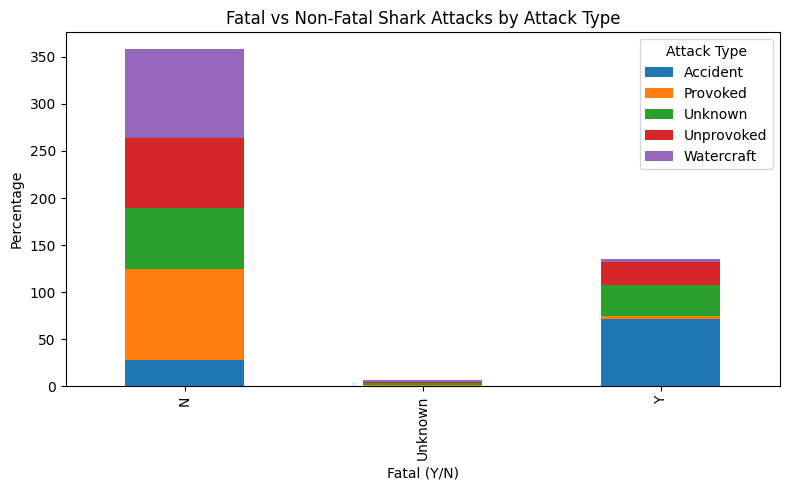

In [57]:
import matplotlib.pyplot as plt

column_percentages.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Fatal vs Non-Fatal Shark Attacks by Attack Type')
plt.xlabel('Fatal (Y/N)')
plt.ylabel('Percentage')
plt.legend(title='Attack Type')
plt.tight_layout()
plt.show()

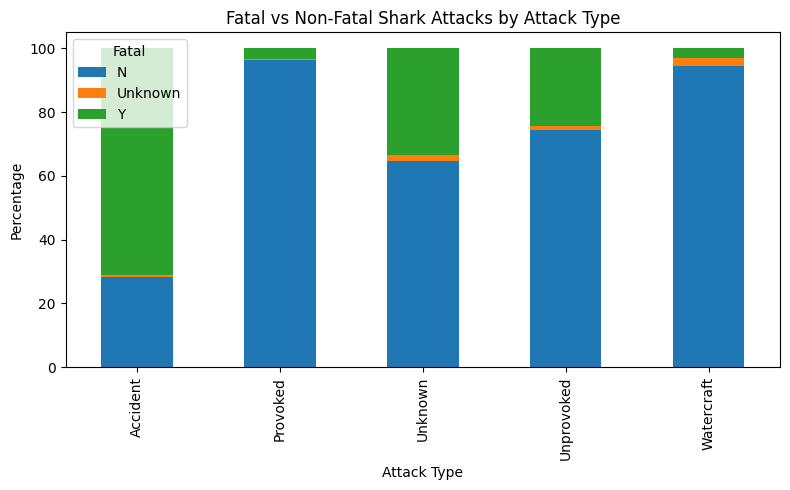

In [58]:
column_percentages.T.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Fatal vs Non-Fatal Shark Attacks by Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Percentage')
plt.legend(title='Fatal')
plt.tight_layout()
plt.show()

### Hypothesis 2

-> A small number of shark species account for the majority of reported shark attacks worldwide. [If proven true, we could argue that most shark species pose little threat to humans as opposed to public opinion]
Result:
Although there are more than 530 known shark species worldwide, our analysis shows that only five species account for the majority of reported shark attacks. 

In [68]:
#calculating number of attacks per species
df['species_standardized'].value_counts().sum()

#substracts Unknown from the list
attacks_species = len(df['species_standardized']) - (df['species_standardized'] == "Unknown").sum()
attacks_species

#shows the top 5 species
df['species_standardized'].value_counts().head(6)

species_standardized
Unknown              4908
Great White Shark     756
Tiger Shark           347
Bull Shark            269
Blacktip Shark        133
Nurse Shark           113
Name: count, dtype: int64

In [61]:
species_counts = df['species_standardized'].value_counts().head(6)

In [69]:
#creating the table to show results
species_counts = (
    df[df["species_standardized"] != "Unknown"]["species_standardized"]
    .value_counts()
)

# Top 5 species
top5 = species_counts.head(5)

# Group the remaining species as Other
other = species_counts.iloc[5:].sum()

top5.loc["Other"] = other

# Calculate percentages
species_percentages = (top5 / top5.sum()) * 100

# Create the final table
Species = pd.DataFrame({
    "Species": top5.index,
    "Attacks": top5.values,
    "Percentage (%)": species_percentages.round(1).values
})

Species

,Species,Attacks,Percentage (%)
0,Great White Shark,756,34.5
1,Tiger Shark,347,15.9
2,Bull Shark,269,12.3
3,Blacktip Shark,133,6.1
4,Nurse Shark,113,5.2
5,Other,571,26.1


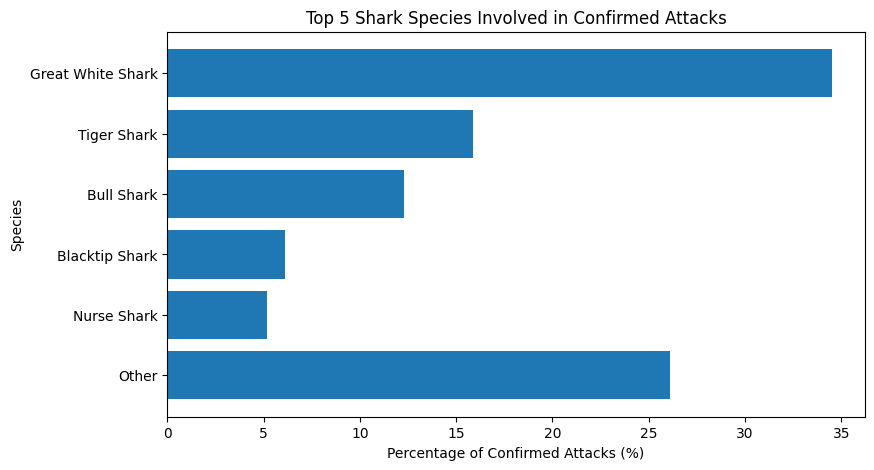

In [70]:
#creating the graph
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.barh(
    Species["Species"],
    Species["Percentage (%)"]
)

plt.xlabel("Percentage of Confirmed Attacks (%)")
plt.ylabel("Species")
plt.title("Top 5 Shark Species Involved in Confirmed Attacks")

plt.gca().invert_yaxis()

plt.show()

### Hypothesis 3

Surfing is the most likely activity to be at risk of shark attack and also the most likely to result in fatal attacks.

In [71]:
table_act= df.groupby(['fatal_y/n', 'activity_category']).size().unstack(fill_value=0)
table_act

activity_category,"Boating, Kayaking & Paddling",Diving & Snorkeling,Fishing & Spearfishing,Other Maritime Activity,Rescue & Emergency Response,"Research, Media & Wildlife Interaction",Shore & Beach Activities,Surfing & Board Sports,Swimming & Recreation,Training & Expeditions,Unknown / Unspecified
fatal_y/n,,,,,,,,,,,
N,206,558,1010,215,11,29,323,1440,852,3,316
Unknown,5,5,6,3,0,0,2,6,10,0,35
Y,180,182,174,151,7,0,45,118,532,1,110


In [72]:
column_percentages_act = table_act.div(table_act.sum(axis=0), axis=1) * 100
column_percentages_act

activity_category,"Boating, Kayaking & Paddling",Diving & Snorkeling,Fishing & Spearfishing,Other Maritime Activity,Rescue & Emergency Response,"Research, Media & Wildlife Interaction",Shore & Beach Activities,Surfing & Board Sports,Swimming & Recreation,Training & Expeditions,Unknown / Unspecified
fatal_y/n,,,,,,,,,,,
N,52.685422,74.899329,84.873950,58.265583,61.111111,100.0,87.297297,92.071611,61.119082,75.0,68.546638
Unknown,1.278772,0.671141,0.504202,0.813008,0.000000,0.0,0.540541,0.383632,0.717360,0.0,7.592191
Y,46.035806,24.429530,14.621849,40.921409,38.888889,0.0,12.162162,7.544757,38.163558,25.0,23.861171


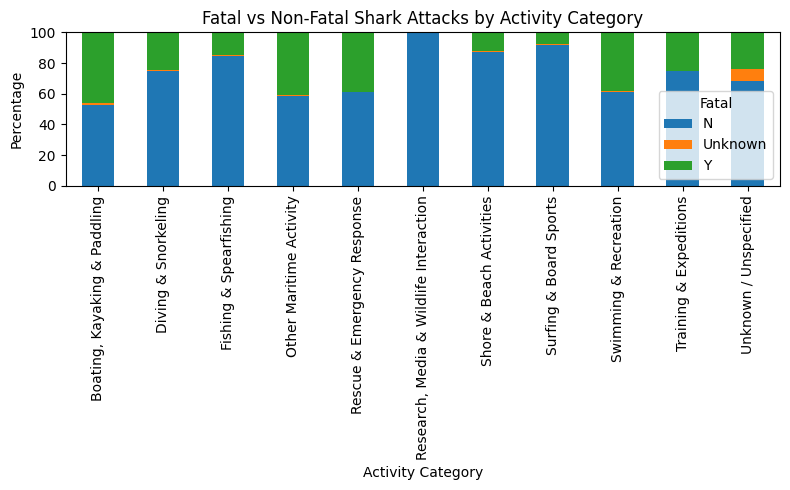

In [73]:
column_percentages_act.T.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Fatal vs Non-Fatal Shark Attacks by Activity Category')
plt.xlabel('Activity Category')
plt.ylabel('Percentage')
plt.legend(title='Fatal')
plt.tight_layout()
plt.show()

In [74]:
top_activities = table_act.sum(axis=0).nlargest(10).index

column_percentages_act_top = column_percentages_act[top_activities]

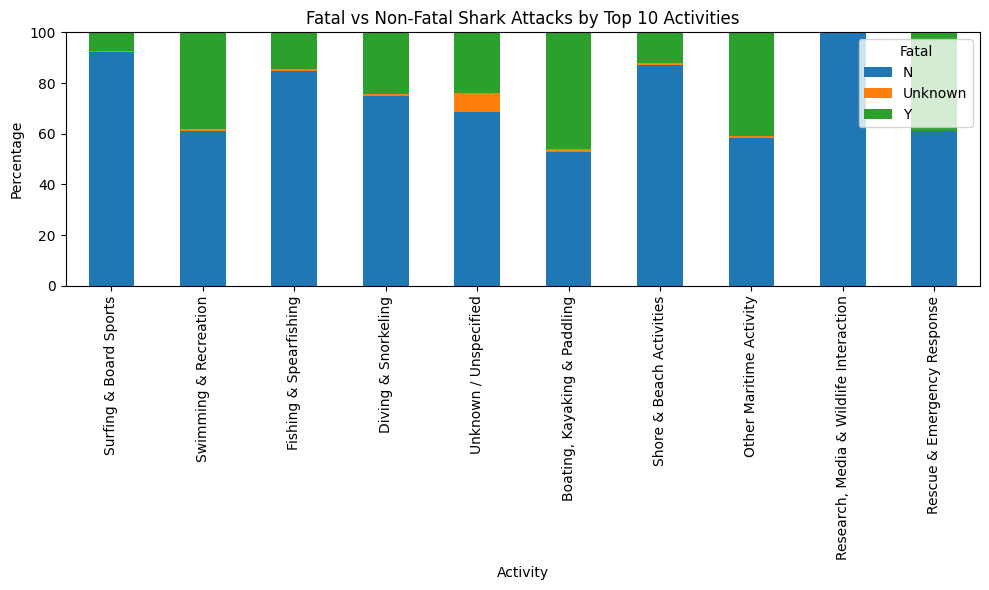

In [75]:
column_percentages_act_top.T.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Fatal vs Non-Fatal Shark Attacks by Top 10 Activities')
plt.xlabel('Activity')
plt.ylabel('Percentage')
plt.legend(title='Fatal')
plt.tight_layout()
plt.show()